# **FORWARD MODEL OF VEHICLE LATERAL DYNAMICS**

This notebook reproduces the same example presented in *lateral_dynamics_model.ipynb*, but this time the implementation is done directly in **Torch** rather than **nnodely**.  

Here, a Model-Structured Neural Network for vehicle lateral dynamics is presented. The dataset used to train the network was collected in CarMaker14 using a 14 Dof vehicle model, the Kia_EV6_demo, an electric car. The training and validation set were collected on a custom track with a spread range of cruvature values and different corner types, from constant radius corner to clothoids. Three different driver profiles were adopted in order to cover a larger values of accelerations, "normal", "aggressive" and "prudent" respectively. Every dataset was then mirrored in order to avoid offsets in the training, assuming that the vehicle can be approximated to be reasonably symmetric in right and left corners.
Finally, the test telemetries were collected on a different track to proove the robustness of the trained network.

## Initialization

In [ ]:
# Import necessary packages
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset

# import a library for plots
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
import matplotlib.pyplot as plt

plt.close("all")
SMALL_SIZE = 14
MEDIUM_SIZE = 22
BIGGER_SIZE = 26
plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc("grid", linestyle="--", color="grey")

# Congigurations
device = "cpu"
print(f"Using {device} device")

torch.manual_seed(1)
np.random.seed(1)

path_folder = "trained_models"  # folder to save the model

Using cpu device


# MS-NN model

The structure of the Model-Structured Neural Network is derived from the description of the lateral dynamic performance of the vehicles through the understeering gradient that describe the correction to be applied with respect to the kinematic (or Ackermann) steering. In particular, denoting with $\delta$ the steering angle at wheels (note that $\delta = \delta_{sw}/\tau_{sw}$, where $\delta_{sw}$ is the steering wheel angle and $\tau_{sw}$ is the steering ratio), the relationship between steer angle and curvature $\kappa$ is:
$$
\rho = \frac{\delta}{1+A v_x^2}
$$
where the parameter $A$ is generally called "understeering gradient". 

The **FirFuzzyLayer** implements the equivalent of a *LoacalModel* composed of *FIR filters* activated by *Fuzzy* **TriangularMembershipFunction** on forward speed takes into account the dynamic response of the system that is function of the speed.  
The **UsFuzzyLayer** implements another *LocalModel* that applies the algebraic relation above as function of the learnable parameter **A** that varies as function of the longitudinal acceleration.  
Finally, the **LateralDynamics** evaluates the output curvature as the product of the two local models outputs.

![](figs/fig_model_torch.png)


In [3]:
# triangular activation function
class TriangularMembershipFunction(nn.Module):
    def __init__(self, centers: list) -> None:
        super().__init__()
        self.centers = torch.tensor(centers, dtype=torch.float32)  # (C,)
        self.C = self.centers.numel()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x:      (batch,1)
        out:    (batch,C)    -> membership per channel/centre
        """
        # get sizes
        batch = x.size(0)
        C = self.C
        centers = self.centers

        # triangural membership function initalization
        phi = torch.zeros(batch, self.C)
        x = x.squeeze(1)  # (C,)

        # evaluate channel width and ceneters
        x_contig = x.contiguous()
        idx0 = torch.clip(torch.bucketize(x_contig, centers) - 1, 0, C - 2)  # [0, C-2]
        idx1 = idx0 + 1  # [1, C-1]
        c0 = centers[idx0]  # left center
        c1 = centers[idx1]  # right center
        ch_w = c1 - c0  # channels distance

        b = torch.arange(batch)

        phi[b, idx0] = torch.clip((c1 - x) / ch_w, 0, 1)  # left channel weight
        phi[b, idx1] = torch.clip((x - c0) / ch_w, 0, 1)  # right channel width

        return phi  # (batch, C)


class FirFuzzyLayer(nn.Module):
    def __init__(self, channels: list, window: int) -> None:
        super().__init__()
        self.C = len(channels)
        self.phi_layer = TriangularMembershipFunction(
            channels
        )  # activation functon weights
        self.fir_layer = nn.Conv1d(  # parallel fir filters
            in_channels=self.C,
            out_channels=self.C,
            kernel_size=window,
            groups=self.C,
            bias=False,
        )
        nn.init.constant_(self.fir_layer.weight, 1.0)
        self.W_fir = torch.tensor(
            [[np.exp(-((i / (window / 2)) ** 2))] for i in range(-window + 1, 1)],
            dtype=torch.float32,
        ).view(1, 1, -1)

    def forward(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        """
        x:      (batch,window)     -> input signal with time windows
        a:      (batch,1)          -> activation function input
        out:    (batch,1)          -> interpolated fir output
        """
        # evaluate membership function
        phi = self.phi_layer(a)  # (batch, C)

        # replicate input for Conv1d
        x_fir = x.unsqueeze(1) * self.W_fir  # (batch, 1, window)
        x_fir = x_fir.repeat(1, self.C, 1)  # (batch, C, window)
        y = self.fir_layer(x_fir)  # (batch, C, 1)
        # evaluate weightet output
        y = y.squeeze(-1)  # (batch, C)
        y = phi * y

        return y.sum(dim=1).unsqueeze(-1)  # (batch,1)


class UsFuzzyLayer(nn.Module):
    def __init__(self, channels: list) -> None:
        super().__init__()
        self.C = len(channels)
        self.phi_layer = TriangularMembershipFunction(channels)
        self.A = nn.Parameter(1e-5 * torch.ones(1, self.C))

    def forward(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        """
        x:     (batch,1)      -> input signal
        a:      (batch,1)      -> activation input
        out:    (batch,1)      -> output
        """
        # evaluate membership function
        phi = self.phi_layer(a)  # (batch,1)

        # replicate for channels
        x = x.repeat(1, self.C)  # (batch,C)

        # evaluate parametric function
        y = 1 / (1 + self.A * x**2)
        y = phi * y

        return y.sum(dim=1).unsqueeze(-1)  # (batch,1)


class LateralDynamics(nn.Module):
    def __init__(self, chan_vx: list, chan_ax: list, window: int) -> None:
        super().__init__()
        self.fir_layer = FirFuzzyLayer(chan_vx, window)
        self.us_layer = UsFuzzyLayer(chan_ax)

    def forward(
        self, steer: torch.Tensor, vx: torch.Tensor, ax: torch.Tensor
    ) -> torch.Tensor:
        """
        steer:      (batch,window)  -> steer time window
        vx:         (batch,1)       -> vx last
        ax:         (batch,1)       -> ax last
        out:        (batch,1)       -> rho next
        """
        # apply fir
        rho_kin = self.fir_layer(steer, vx)
        # apply us correction
        corr_kus = self.us_layer(vx, ax)

        return rho_kin * corr_kus

In [4]:
# ----------------------------------------------------------------
# Hyperparameters
# ----------------------------------------------------------------
samples_past_steer = (
    30  # number of samples in the past for the steering wheel angle prediction
)
n_channels_vx = 8  # number of channels for activation function vx
chan_vx = list(np.linspace(8, 23, num=n_channels_vx))  # centers of the channels vx
chan_ax = [-2, -1, 0.0, 1.0, 2.0]  # centers of the channels ax

prediction = 80  # 4s prediction

# ----------------------------------------------------------------
#  MODEL
# ----------------------------------------------------------------
model = LateralDynamics(chan_vx, chan_ax, samples_past_steer)

## Training, validation and test datrasets

In this section the datasets used in training, validation and test are created. Differently from nnodely, where the time windows are automatically generated, it is important to pay attention to the dimensions while creating the datasets. Below, different dataset for non-recurrent and recurrent training are created. 

In [5]:
data_training = "dataset/training/*.csv"
data_valid = "dataset/validation/*.csv"
data_test = "dataset/test/*.csv"

head = ["ax", "vx", "curv", "steer"]
sampling = 0.05


# loading of csv datasets
import pandas as pd
import glob


def load_csv_list(data_path: str):
    dfs = []
    for file in glob.glob(data_path):
        df = pd.read_csv(file)
        df = df[head].reset_index(drop=True)
        dfs.append(df)
    return dfs


class VehicleDataset(Dataset):
    def __init__(self, df: pd.DataFrame, past_samples: int, prediction: int):
        self.lb = past_samples
        self.lf = prediction
        self.df = df

        self.steer = torch.tensor(df["steer"].values, dtype=torch.float32)
        self.vx = torch.tensor(df["vx"].values, dtype=torch.float32)
        self.ax = torch.tensor(df["ax"].values, dtype=torch.float32)
        self.curv = torch.tensor(df["curv"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.df) - self.lb - self.lf - 1

    def __getitem__(self, i):
        steer = self.steer[i : i + self.lb + self.lf]

        if self.lf > 0:
            vx = self.vx[i + self.lb - 1 : i + self.lb + self.lf - 1]
            ax = self.ax[i + self.lb - 1 : i + self.lb + self.lf - 1]
            curv = self.curv[i + self.lb : i + self.lb + self.lf]
        else:
            vx = self.vx[i + self.lb - 1].unsqueeze(-1)
            ax = self.ax[i + self.lb - 1].unsqueeze(-1)
            curv = self.curv[i + self.lb].unsqueeze(-1)

        return steer, vx, ax, curv


# Concatenate datasets
def build_dataset(csv_path, past_samples, prediction):
    dfs = load_csv_list(csv_path)
    datasets = [
        VehicleDataset(df, past_samples, prediction)
        for df in dfs
        if len(df) > past_samples + prediction + 1
    ]
    return ConcatDataset(datasets)


# non recurrent dataset
train_dataset = build_dataset(data_training, samples_past_steer, prediction=0)
valid_dataset = build_dataset(data_valid, samples_past_steer, prediction=0)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=64, shuffle=True)

# recurrent dataset
train_dataset_rec = build_dataset(data_training, samples_past_steer, prediction)
valid_dataset_rec = build_dataset(data_valid, samples_past_steer, prediction)

train_dataloader_rec = DataLoader(train_dataset_rec, batch_size=64, shuffle=True)
valid_dataloader_rec = DataLoader(valid_dataset_rec, batch_size=64, shuffle=True)

# test set
test_dataset = build_dataset(data_test, samples_past_steer, prediction=0)
test_dataloader_analyse = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Training

The training is done in two steps. The first training has not prediction samples in the future, that corresponds to train the network uniquely on the curvature loss function. In this way the network weights are adjusted. The second step of training is more a refining of the network weigths, including a future time window on which the integral error is evaluated.

Two loss terms are defined, both of them use the MSE as loss function.  
The first loss is evaluated on the curvature error: the next-step curvature predicted by the model is compared to the dataset curvature.  
The second loss is evaluated on the heading error*: both reference heading and predicted heading are evaluated starting form the curvature values. 

*assuming steady-state curvature, the following relation holds: $\psi = \int \kappa v_x \, \mathrm{d}t$, where $\psi$ denotes the heading angle.

The second loss term provided more robustness to the network, reducing possible biases. The dependency to forward speed, moreover, weights the loss term reducing the bias espetially for high speed, where a bias is more determinant in the tracking error of the desired trajectory.

In [6]:
# Loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

| EPOCHS  |  train_loss  |  valid_loss  |
|    1    | 1.205848e+01 | 3.993303e+00 |
|    2    | 3.601545e+00 | 2.272017e+00 |
|    3    | 2.269297e+00 | 1.560794e+00 |
|    4    | 1.623210e+00 | 1.166077e+00 |
|    5    | 1.231791e+00 | 9.115995e-01 |
|    6    | 9.694558e-01 | 7.314101e-01 |
|    7    | 7.785340e-01 | 5.986812e-01 |
|    8    | 6.348477e-01 | 4.952880e-01 |
|    9    | 5.227449e-01 | 4.137729e-01 |
|   10    | 4.325497e-01 | 3.469233e-01 |
|   11    | 3.591937e-01 | 2.921307e-01 |
|   12    | 2.987542e-01 | 2.463117e-01 |
|   13    | 2.482705e-01 | 2.072196e-01 |
|   14    | 2.057386e-01 | 1.743322e-01 |
|   15    | 1.700803e-01 | 1.459871e-01 |
|   16    | 1.399665e-01 | 1.219467e-01 |
|   17    | 1.145317e-01 | 1.010900e-01 |
|   18    | 9.316733e-02 | 8.357940e-02 |
|   19    | 7.517885e-02 | 6.819770e-02 |
|   20    | 6.023755e-02 | 5.558151e-02 |
|   21    | 4.778022e-02 | 4.462547e-02 |
|   22    | 3.758923e-02 | 3.550482e-02 |
|   23    | 2.931881e-02 | 2.79429

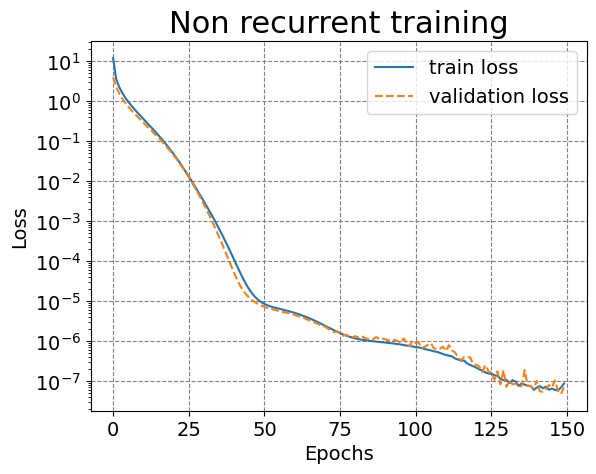

In [7]:
# ------------------------------------------------------------------------
# Non-recurrent training
# ------------------------------------------------------------------------
EPOCHS = 150

train_loss_list = []
valid_loss_list = []


def inference(
    steer: torch.Tensor, vx: torch.Tensor, ax: torch.Tensor, curv: torch.Tensor
):

    # Make one-step prediction
    output = model(steer, vx, ax)
    # Compute the loss
    loss = loss_fn(output, curv)

    return loss


def train_one_epoch():
    avg_loss = 0.0

    for i, data in enumerate(train_dataloader):
        steer, vx, ax, curv = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # compute loss and its gradient
        loss = inference(steer, vx, ax, curv)
        loss.backward()

        avg_loss += loss.item()
        # Adjust learning weights
        optimizer.step()

    return avg_loss / len(train_dataloader)


print("| {:^7} | {:^12} | {:^12} |".format("EPOCHS", "train_loss", "valid_loss"))
for epoch in range(EPOCHS):
    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch()

    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()
    avg_vloss = 0.0

    with torch.no_grad():
        for i, vdata in enumerate(valid_dataloader):
            steer, vx, ax, curv = vdata

            vloss = inference(steer, vx, ax, curv)
            avg_vloss += vloss.item()
        avg_vloss /= len(valid_dataloader)

    # save the total losses
    train_loss_list.append(avg_loss)
    valid_loss_list.append(avg_vloss)

    print("| {:^7} | {:^12.6e} | {:^12.6e} |".format(epoch + 1, avg_loss, avg_vloss))
    epoch += 1

plt.figure()
plt.title("Non recurrent training")
plt.plot(train_loss_list, label="train loss")
plt.plot(valid_loss_list, "--", label="validation loss")
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# Save the weights
torch.save(model.state_dict(), path_folder + "/model.pt")

| EPOCHS  |  train_loss  |  valid_loss  |
|    1    | 1.377889e-04 | 2.693818e-05 |
|    2    | 2.623087e-05 | 4.141323e-05 |
|    3    | 2.588223e-05 | 2.720195e-05 |
|    4    | 2.534634e-05 | 2.554914e-05 |
|    5    | 2.738388e-05 | 2.576481e-05 |
|    6    | 2.765964e-05 | 3.931546e-05 |
|    7    | 2.544308e-05 | 2.646154e-05 |
|    8    | 2.837828e-05 | 3.363704e-05 |
|    9    | 2.730536e-05 | 4.175908e-05 |
|   10    | 2.756178e-05 | 2.300445e-05 |
|   11    | 3.432054e-05 | 2.018997e-05 |
|   12    | 2.904275e-05 | 3.317036e-05 |
|   13    | 2.574582e-05 | 1.755240e-05 |
|   14    | 2.493574e-05 | 2.667926e-05 |
|   15    | 2.635224e-05 | 3.085884e-05 |
|   16    | 2.881143e-05 | 4.300633e-05 |
|   17    | 2.687611e-05 | 2.373896e-05 |
|   18    | 2.842827e-05 | 3.746086e-05 |
|   19    | 2.865635e-05 | 2.058030e-05 |
|   20    | 2.820284e-05 | 2.592496e-05 |


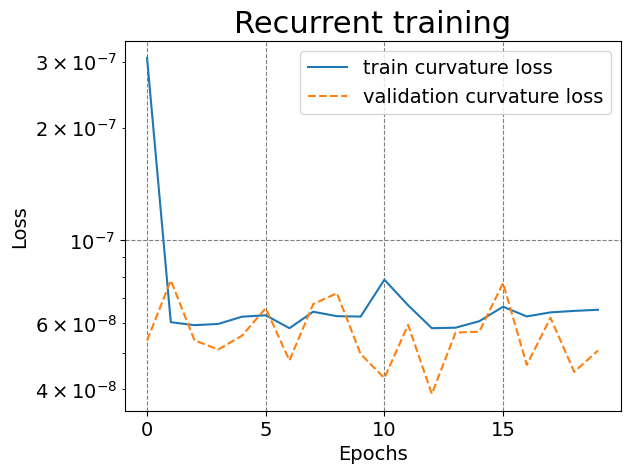

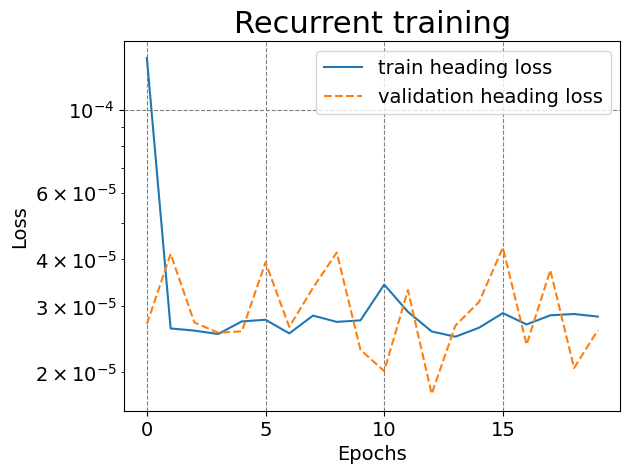

In [8]:
# ------------------------------------------------------------------------
# Recurrent training
# ------------------------------------------------------------------------
EPOCHS = 20

curv_loss_list = []
head_loss_list = []
curv_vloss_list = []
head_vloss_list = []


def inference_rec(
    steer: torch.Tensor, vx: torch.Tensor, ax: torch.Tensor, curv: torch.Tensor
):

    # recurrent training
    psi0_ref = 0
    psi_ref = 0
    psi0_comp = 0
    psi_comp = 0
    loss_curv = 0
    loss_head = 0

    for j in range(prediction):
        steer_k = steer[:, j : j + samples_past_steer]
        vx_k = vx[:, j].unsqueeze(-1)
        ax_k = ax[:, j].unsqueeze(-1)
        curv_k = curv[:, j].unsqueeze(-1)

        # Make one-step prediction
        output = model(steer_k, vx_k, ax_k)
        # Compute the loss
        loss_curv += loss_fn(output, curv_k)
        psi_ref = psi0_ref + curv_k * vx_k * sampling
        psi_comp = psi0_comp + output * vx_k * sampling
        loss_head += loss_fn(psi_ref, psi_comp)

        psi0_comp = psi_comp
        psi0_ref = psi_ref

    loss_curv = loss_curv / prediction
    loss_head = loss_head / prediction

    loss = loss_curv + loss_head

    return loss, loss_curv, loss_head


def train_one_epoch_rec():
    avg_loss = 0.0
    avg_curv_loss = 0.0
    avg_head_loss = 0.0

    for i, data in enumerate(train_dataloader_rec):
        steer, vx, ax, curv = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # compute loss and its gradient
        loss, loss_curv, loss_head = inference_rec(steer, vx, ax, curv)
        loss.backward()

        avg_loss += loss.item()

        avg_curv_loss += loss_curv.item()
        avg_head_loss += loss_head.item()

        # Adjust learning weights
        optimizer.step()

    return (
        avg_loss / len(train_dataloader_rec),
        avg_curv_loss / len(train_dataloader_rec),
        avg_head_loss / len(train_dataloader_rec),
    )


print("| {:^7} | {:^12} | {:^12} |".format("EPOCHS", "train_loss", "valid_loss"))
for epoch in range(EPOCHS):
    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss, avg_curv_loss, avg_head_loss = train_one_epoch_rec()

    curv_loss_list.append(avg_curv_loss)
    head_loss_list.append(avg_head_loss)

    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()
    avg_vloss = 0.0
    avg_vloss_curv = 0.0
    avg_vloss_head = 0.0
    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(valid_dataloader_rec):
            steer, vx, ax, curv = vdata

            vloss, vloss_curv, vloss_head = inference_rec(steer, vx, ax, curv)
            avg_vloss += vloss.item()
            avg_vloss_curv += vloss_curv.item()
            avg_vloss_head += vloss_head.item()

        avg_vloss /= len(valid_dataloader_rec)
        avg_vloss_curv /= len(valid_dataloader_rec)
        avg_vloss_head /= len(valid_dataloader_rec)
    head_vloss_list.append(avg_vloss_head)
    curv_vloss_list.append(avg_vloss_curv)

    print("| {:^7} | {:^12.6e} | {:^12.6e} |".format(epoch + 1, avg_loss, avg_vloss))
    epoch += 1


plt.figure()
plt.title("Recurrent training")
plt.plot(curv_loss_list, label="train curvature loss")
plt.plot(curv_vloss_list, "--", label="validation curvature loss")
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.title("Recurrent training")
plt.plot(head_loss_list, label="train heading loss")
plt.plot(head_vloss_list, "--", label="validation heading loss")
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


# Save the weights
torch.save(model.state_dict(), path_folder + "/model.pt")

## Test set

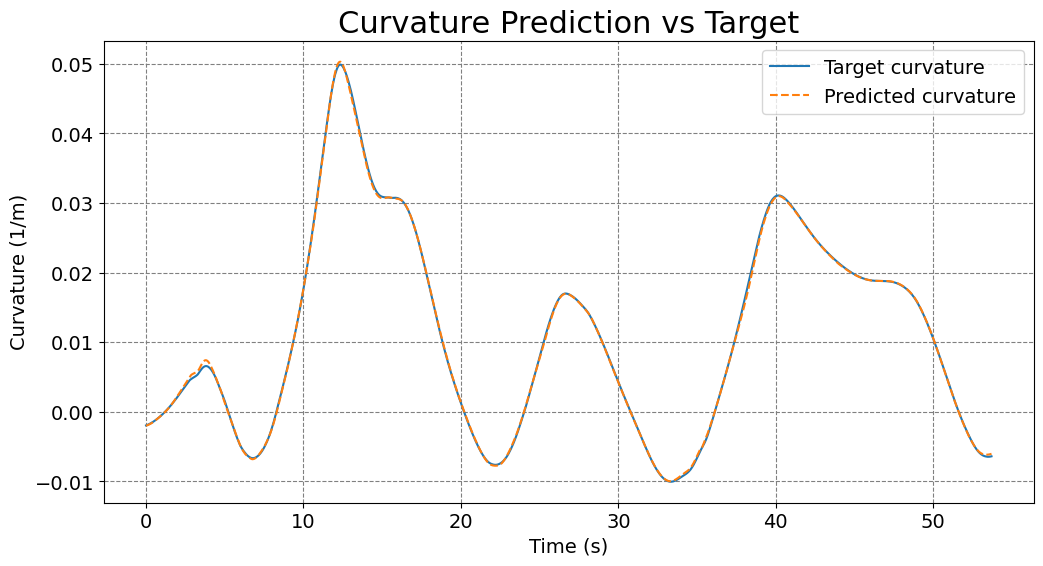

In [ ]:
# inference
model = LateralDynamics(chan_vx, chan_ax, samples_past_steer)
model.load_state_dict(torch.load(path_folder + "/vehicle_model_torch.pt"))

curv_targ = []
curv_out = []

for i, data in enumerate(test_dataloader_analyse):
    steer, vx, ax, curv = data

    model.eval()
    curv_ = model(steer, vx, ax)

    curv_targ.append(curv)
    curv_out.append(curv_)

curv_targ = torch.cat(curv_targ, dim=0).squeeze().numpy()
curv_out = torch.cat(curv_out, dim=0).squeeze().detach().numpy()

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(
    sampling * np.linspace(0, len(curv_targ), len(curv_targ)),
    curv_targ,
    label="Target curvature",
)
plt.plot(
    sampling * np.linspace(0, len(curv_out), len(curv_out)),
    curv_out,
    "--",
    label="Predicted curvature",
)
plt.xlabel("Time (s)")
plt.ylabel("Curvature (1/m)")
plt.title("Curvature Prediction vs Target")
plt.legend()
plt.grid()
plt.show()

## Fir weights

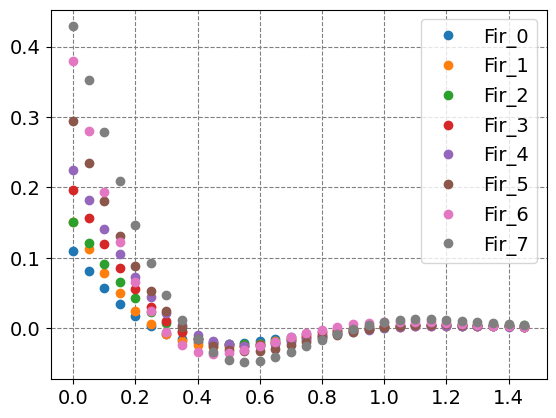

In [10]:
sampling = 0.05
W_fir = torch.tensor(
    [
        [np.exp(-((i / (samples_past_steer / 2)) ** 2))]
        for i in range(-samples_past_steer + 1, 1)
    ],
    dtype=torch.float32,
).squeeze(-1)

for name, param in model.named_parameters():
    if name.startswith("fir_layer"):
        fir_param = param

plt.figure()

for i in range(fir_param[:, 0, 0].detach().numpy().size):
    weight_loc = fir_param[i, 0, :] * W_fir
    weight_loc = weight_loc.detach().numpy()
    time = np.linspace(0, sampling * (len(weight_loc) - 1), len(weight_loc))
    plt.plot(time, np.flip(weight_loc), "o", label=f"Fir_{i}")
plt.legend()
plt.grid(True)
plt.show()